In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from math import e
import warnings
warnings.filterwarnings("ignore")

beta_0 = -1.5
beta_1 = -3.0
beta_2 = 2.2

x_1 = 0.4
x_2 = 0.7

z = beta_0 + beta_1 * x_1 + beta_2 * x_2
p = 1 / (1 + pow(e, -z))
Odds = p / (1 - p)

or_1 = pow(e, beta_1)
or_2 = pow(e, beta_2)

print("Log-odds:", z)
print("Probability of attrition:",p)
print("Odds of attrition:", Odds)
print("Odds ratios for b1 and b2:",or_1,", ",or_2)

Log-odds: -1.1600000000000001
Probability of attrition: 0.23866728515708957
Odds of attrition: 0.31348618088260527
Odds ratios for b1 and b2: 0.04978706836786395 ,  9.025013499434122


In [ ]:
table_8 = pd.DataFrame(
    {
        "Employee": [1, 2, 3, 4, 5, 6, 7, 8],
        "x_1, (Satisfaction)": [0.2, 0.9, 0.3, 0.8, 0.1, 0.7, 0.4, 0.6],
        "x_2, (Workload)": [0.8, 0.2, 0.7, 0.3, 0.9, 0.4, 0.6, 0.5],
        "Left": [1, 0, 1, 0, 1, 0, 1, 0],
    }
)

X_train = table_8[["x_1, (Satisfaction)","x_2, (Workload)"]]

y_train = table_8["Left"]

log_reg=LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train,y_train)
beta_0=log_reg.intercept_[0]
beta_1=log_reg.coef_[0][0]
beta_2=log_reg.coef_[0][1]
print("Learned coefficients:")
print(" beta_1 (Satisfaction):", beta_1)
print(" beta_2 (Workload):", beta_2)
print(" beta_0 (intercept):", beta_0)

print(" beta_1's odd ratio:", e**beta_1)
print(" beta_2's odd ratio:", e**beta_2)
print(" beta_0's odd ratio:", e**beta_0)

x_1=0.5
x_2=0.5
z = beta_0 + beta_1 * x_1 + beta_2 * x_2
p = 1 / (1 + pow(e, -z))

print(p)


Learned coefficients:
 beta_1 (Satisfaction): -0.8036297293076762
 beta_2 (Workload): 0.6359686067542903
 beta_0 (intercept): 0.05199662545020391
 beta_1's odd ratio: 0.44770097796927827
 beta_2's odd ratio: 1.8888508093375083
 beta_0's odd ratio: 1.0533721878504654
0.4920421880688936


In [20]:
turnover = 25000
intervention = 3000
success = 0.5

p = 0.6
cost_without = p * turnover
cost_with = intervention + p * (1-success) * turnover
ev = cost_without - cost_with
print("Expected value for p=0.6: ", ev)

threshold = intervention / (turnover * success)
print("Optimal threshold: p ≥ ",threshold)

avg_p = (1 + threshold) / 2
percent_intervened = 1 - threshold
savings_per = (avg_p * turnover) - (intervention + avg_p * (1-success) * turnover)
total_savings = 100 * percent_intervened * savings_per
print("Expected annual savings (100 employees):", total_savings)

Expected value for p=0.6:  4500.0
Optimal threshold: p ≥  0.24
Expected annual savings (100 employees): 361000.0


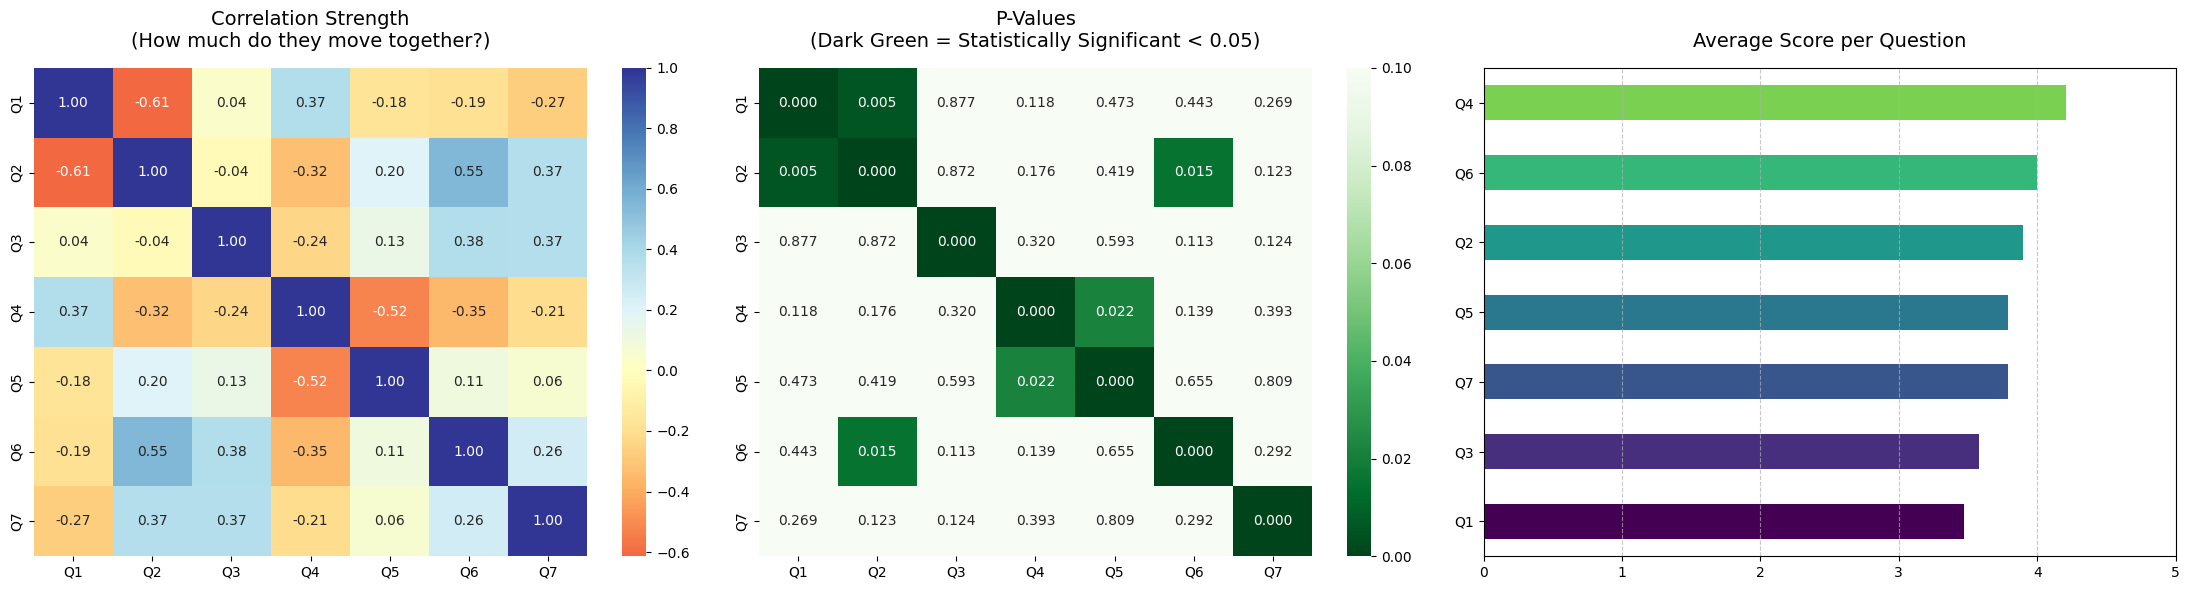

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Prepare the data
data = {
    'Q1': [5,4,4,3,2,4,3,3,3,3,3,5,5,3,1,4,3,3,5],
    'Q2': [2,5,3,5,5,4,4,3,4,4,4,4,1,5,5,3,5,4,4],
    'Q3': [2,5,4,3,2,5,5,4,3,4,3,4,4,3,4,5,4,2,2],
    'Q4': [5,5,4,3,5,5,3,4,4,4,5,4,5,4,4,4,3,4,5],
    'Q5': [3,2,2,4,3,4,5,3,4,4,3,5,4,4,5,4,5,4,4],
    'Q6': [2,5,5,5,3,5,4,4,4,5,2,4,2,5,5,4,4,3,5],
    'Q7': [4,5,5,3,4,5,5,2,4,4,3,5,2,4,5,3,4,4,1]
}
df = pd.DataFrame(data)

# 2. Calculate Correlation and P-values
corr_matrix = df.corr()
p_matrix = df.apply(lambda x: df.apply(lambda y: pearsonr(x, y)[1]))

# 3. Create Visualizations
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot 1: Correlation Heatmap ---
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', center=0, ax=axes[0], fmt=".2f")
axes[0].set_title('Correlation Strength\n(How much do they move together?)', fontsize=14, pad=15)

# --- Plot 2: P-Value Heatmap ---
# We use a log scale or highlight values < 0.05
sns.heatmap(p_matrix, annot=True, cmap='Greens_r', vmax=0.1, ax=axes[1], fmt=".3f")
axes[1].set_title('P-Values\n(Dark Green = Statistically Significant < 0.05)', fontsize=14, pad=15)

# --- Plot 3: Average Scores ---
means = df.mean().sort_values()
colors = plt.cm.viridis(np.linspace(0, 0.8, len(means)))
means.plot(kind='barh', color=colors, ax=axes[2])
axes[2].set_title('Average Score per Question', fontsize=14, pad=15)
axes[2].set_xlim(0, 5)
axes[2].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()